# ADIRE Simulation Results

Analysis of the ADIRE (Anchor-Diffed Incremental Re-Embedding) simulation comparing five re-embedding strategies across document sizes, structures, edit types, and edit chains.

## Strategies Compared

| Strategy | How it works | Chunk sizes | Cascade resistant? |
|---|---|---|---|
| **Naive** | Discard all chunks, re-chunk and re-embed from scratch on every edit. The baseline — always pays full cost. | Optimal (greedy combining to ~512 tokens) | N/A |
| **Paragraph-Level Reuse** | Each paragraph is its own chunk (no combining). On edit, hash each paragraph and do a set lookup against old hashes. If a hash matches, reuse the embedding. Fully cascade-resistant but produces highly variable chunk sizes — a 20-char heading and a 1500-char prose block both become individual chunks. | Uncontrolled (1 paragraph = 1 chunk) | Yes |
| **Chunk-Hash Match** | Re-chunk from scratch with greedy combining (same as naive), then hash each new chunk's full text and check if it matches any old chunk. Reuse if so. This is the "common optimization" — it breaks down due to **cascade**: inserting a paragraph near the top shifts all downstream chunk boundaries, so most chunk text hashes change even though the underlying paragraphs are identical. | Optimal (greedy combining) | **No** (cascade) |
| **ADIRE** | Diff old vs new paragraph hash sequences positionally. Identify which chunks contain changed/inserted/deleted paragraphs ("dirty chunks"). Re-chunk only the dirty regions. Unchanged chunks keep their embeddings by design, not by coincidence. | Optimal (greedy combining) | Yes |
| **ADIRE (Wide Window)** | Same as ADIRE, but expands each dirty region to include one neighbor chunk on each side. Trades higher re-embedding cost for better chunk quality — the wider re-chunk region produces boundaries closer to from-scratch optimal, reducing fragment accumulation. | Optimal (fewer fragments) | Yes |

**Key distinction**: Chunk-hash match and ADIRE both use the same greedy combining, but chunk-hash compares *chunk text hashes* (which break on cascade) while ADIRE compares *paragraph hash sequences positionally* (which are cascade-resistant).

**What is cascade?** When a document is re-chunked from scratch using greedy combining, inserting or deleting content shifts all downstream chunk boundaries. A paragraph inserted near the top changes where every subsequent chunk starts and ends — so every downstream chunk has different text, producing a different hash, even though the underlying paragraphs are unchanged. This is the **cascade problem**. A strategy is **cascade-resistant** if edits only affect chunks near the edit point, not the entire document.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from adire.analysis import (
    SAME_GRANULARITY_STRATEGIES,
    STRATEGY_COLORS,
    STRATEGY_LABELS,
    STRATEGY_ORDER,
    chain_results,
    compute_cost_savings,
    format_size_label,
    heatmap_data,
    load_results,
    mean_by,
    pivot_for_grouped_bar,
    single_edit_results,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100


def colors_for(columns):
    """Get fixed colors for strategy columns."""
    return [STRATEGY_COLORS[s] for s in columns]


df = load_results("../results.parquet")
single = single_edit_results(df)
chains = chain_results(df)

print(f"Total rows: {len(df):,}")
print(f"Single-edit: {len(single):,}")
print(f"Chain: {len(chains):,}")

Total rows: 903,000
Single-edit: 900,000
Chain: 3,000


## Data Validation

Verify the dataset is complete and well-formed before analysis.

In [2]:
# --- No missing values ---
assert df.isna().sum().sum() == 0, f"Missing values found:\n{df.isna().sum()[df.isna().sum() > 0]}"

# --- Expected experiment types ---
assert set(df["experiment_type"].unique()) == {"single", "chain"}

# --- All 5 strategies present ---
expected_strategies = {"naive", "paragraph_reuse", "chunk_hash", "adire", "adire_wide_window"}
assert set(df["strategy"].unique()) == expected_strategies

# --- Metrics are in valid ranges ---
for col in ["preservation_rate", "reembedding_rate", "token_savings_rate", "fragment_ratio", "oversized_ratio"]:
    assert (df[col] >= 0.0).all(), f"{col} has negative values"
    assert (df[col] <= 1.0).all(), f"{col} has values > 1.0"

assert (df["chunks_reembedded"] >= 0).all()
assert (df["chunks_reused"] >= 0).all()
assert (df["tokens_reembedded"] >= 0).all()
assert (df["algorithm_time_ms"] >= 0).all()

# --- Chunk counts are consistent ---
assert (df["chunks_reembedded"] + df["chunks_reused"] == df["chunk_count_after"]).all(), \
    "chunks_reembedded + chunks_reused != chunk_count_after"

# --- Naive always has 0% preservation ---
naive = df[df["strategy"] == "naive"]
assert (naive["chunks_reused"] == 0).all(), "Naive strategy should never reuse chunks"
assert (naive["preservation_rate"] == 0.0).all()

# --- Row counts ---
print(f"Single-edit rows: {len(single):,}")
print(f"Chain rows: {len(chains):,}")
print(f"Strategies: {sorted(df['strategy'].unique())}")
print(f"Document sizes: {sorted(df['document_size'].unique())}")
print(f"Document profiles: {sorted(df['document_profile'].unique())}")
print(f"Edit types: {sorted(df['edit_type'].unique())}")
print(f"\nAll validation checks passed.")

Single-edit rows: 900,000
Chain rows: 3,000
Strategies: ['adire', 'adire_wide_window', 'chunk_hash', 'naive', 'paragraph_reuse']
Document sizes: [np.int64(2000), np.int64(5000), np.int64(25000), np.int64(50000), np.int64(100000)]
Document profiles: ['bimodal', 'long_paragraphs', 'mixed', 'oversized_paragraphs', 'short_paragraphs', 'structureless_blob']
Edit types: ['append', 'paragraph_delete', 'paragraph_insert', 'scattered_edits', 'section_insert', 'section_rewrite', 'sentence_addition', 'typo_fix']

All validation checks passed.


## 1. Token Savings Rate by Document Size

**What it measures**: The fraction of total embedding token cost avoided by reusing chunks instead of re-embedding everything.

`token_savings_rate = 1 − (tokens_re-embedded / total_tokens)`

**Why tokens, not chunks?** Chunks vary in size. Reusing a 500-token chunk saves more than reusing a 50-token chunk, but both count as "1 chunk preserved." Token savings rate weights by actual size, making it the fairest cost comparison across all strategies — including paragraph-level reuse, whose chunks are individual paragraphs (much smaller than ADIRE's greedy-combined chunks).

**Example**: A document has 3 chunks totaling 1,200 tokens. After an edit, a strategy re-embeds 1 chunk (400 tokens) and reuses 2 chunks (800 tokens). Token savings rate = 1 − 400/1200 = **66.7%**. If naive re-embeds all 1,200 tokens, its savings rate is **0%**.

**How to read**: Higher is better. At 0% the strategy re-embeds everything (naive). At 100% nothing was re-embedded (no-change fast path).

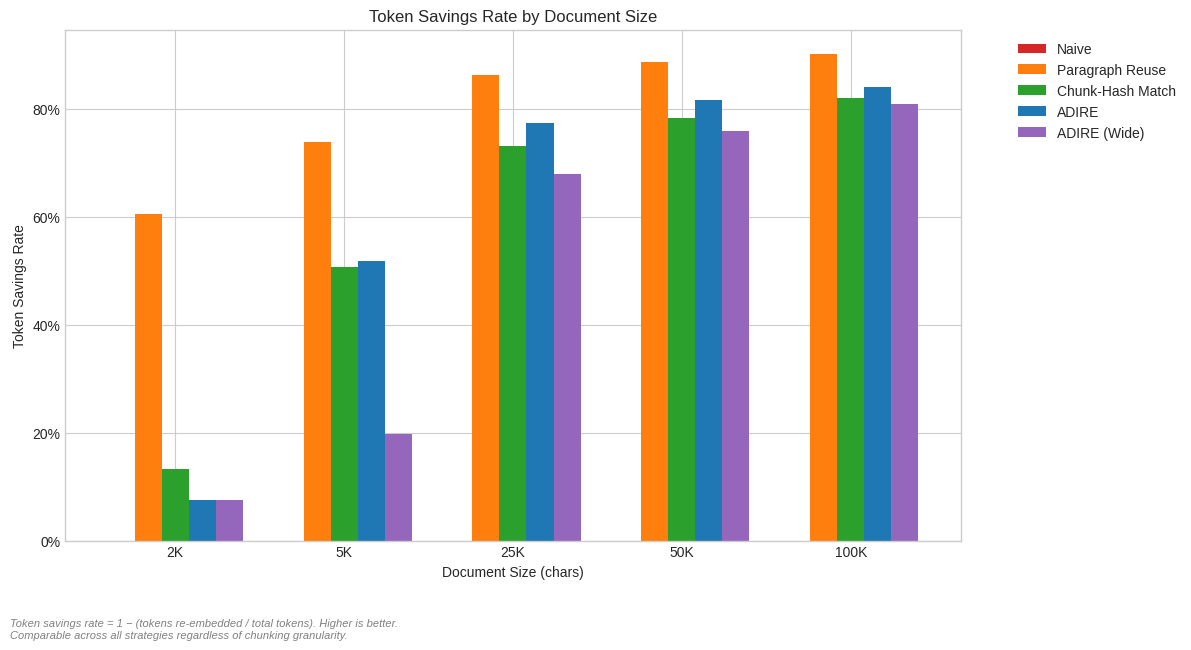

In [3]:
pivoted = pivot_for_grouped_bar(single, "document_size", "token_savings_rate")
fig, ax = plt.subplots()
pivoted.rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.8, ax=ax)
ax.set_xlabel("Document Size (chars)")
ax.set_ylabel("Token Savings Rate")
ax.set_title("Token Savings Rate by Document Size")
ax.set_xticklabels([format_size_label(x) for x in pivoted.index], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Token savings rate = 1 − (tokens re-embedded / total tokens). Higher is better.\n"
    "Comparable across all strategies regardless of chunking granularity.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig01_token_savings_by_size.png", bbox_inches="tight")
plt.show()

## 2. Preservation Rate by Document Size (Same-Granularity Strategies)

**What it measures**: The fraction of output chunks that didn't need a new embedding API call.
Can you elaborate why we don't see
`preservation_rate = chunks_reused / total_chunks`

**Why only same-granularity strategies?** Paragraph-level reuse produces one chunk per paragraph (~50-200 tokens each), while the other strategies use greedy combining (~512 tokens each). A document might have 50 paragraph-chunks but only 10 greedy-combined chunks. Comparing "50% of 50 chunks" vs "50% of 10 chunks" is misleading — they're measuring different things. This chart shows only strategies that use the same chunking granularity.

**Example**: A document has 10 greedy-combined chunks. After a typo fix, ADIRE re-embeds 1 chunk and reuses 9. Preservation rate = 9/10 = **90%**. Chunk-hash match might re-embed 5 (cascade shifted boundaries) = **50%**. Naive always re-embeds all 10 = **0%**.

**How to read**: Higher is better. The gap between chunk-hash match and ADIRE shows the value of positional diffing over text-hash matching.

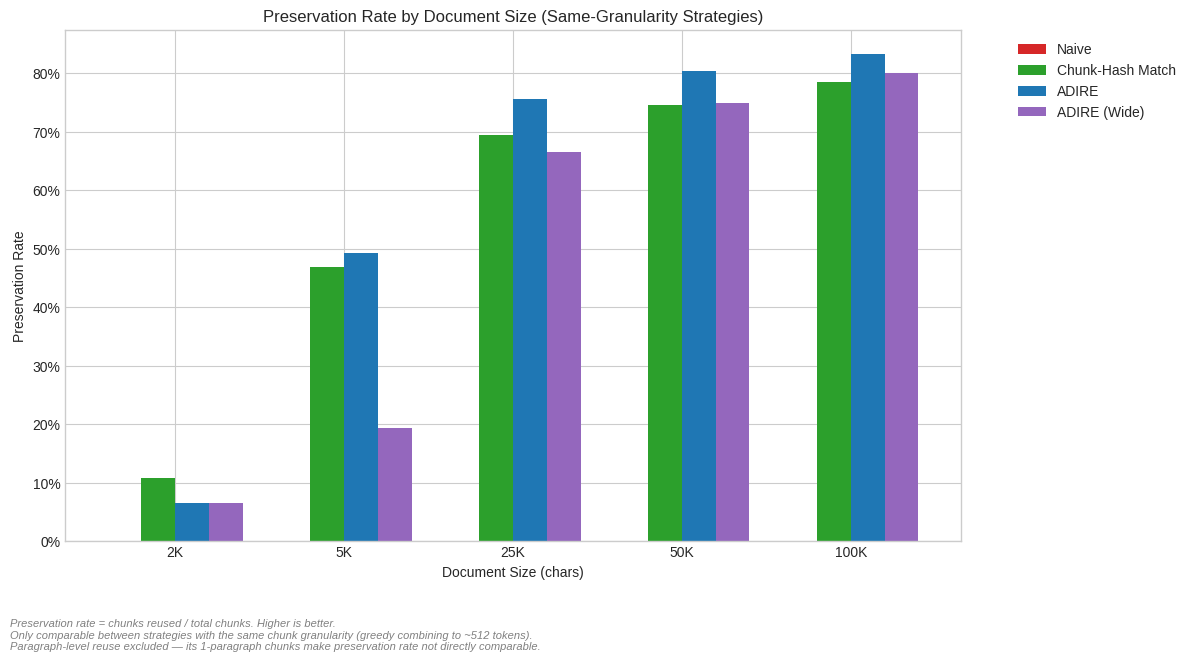

In [4]:
pivoted = pivot_for_grouped_bar(
    single, "document_size", "preservation_rate",
    strategies=SAME_GRANULARITY_STRATEGIES,
)
fig, ax = plt.subplots()
pivoted.rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.8, ax=ax)
ax.set_xlabel("Document Size (chars)")
ax.set_ylabel("Preservation Rate")
ax.set_title("Preservation Rate by Document Size (Same-Granularity Strategies)")
ax.set_xticklabels([format_size_label(x) for x in pivoted.index], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Preservation rate = chunks reused / total chunks. Higher is better.\n"
    "Only comparable between strategies with the same chunk granularity (greedy combining to ~512 tokens).\n"
    "Paragraph-level reuse excluded — its 1-paragraph chunks make preservation rate not directly comparable.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig02_preservation_by_size.png", bbox_inches="tight")
plt.show()

## 3. Preservation Rate by Document Structure

**What it measures**: Same metric as chart 2 (chunks_reused / total_chunks), but grouped by document structure instead of size.

**Why this matters**: ADIRE relies on paragraph boundaries as anchors for change detection. Documents with many short paragraphs (bullet-heavy notes) give fine-grained anchors — edits dirty fewer chunks. Documents with few or no paragraph boundaries (structureless blob, e.g., pasted PDF text) give ADIRE nothing to anchor to — it degrades toward naive behavior.

**Example**: A "mixed" document with 60 paragraphs in 12 chunks: editing 1 paragraph dirties 1 chunk (8% re-embedded). A "structureless blob" with 1 paragraph in 1 chunk: any edit dirties 100%.

**How to read**: Compare across profiles for the same strategy. Profiles where ADIRE's bar drops significantly (e.g., structureless_blob) indicate document types where ADIRE adds less value.

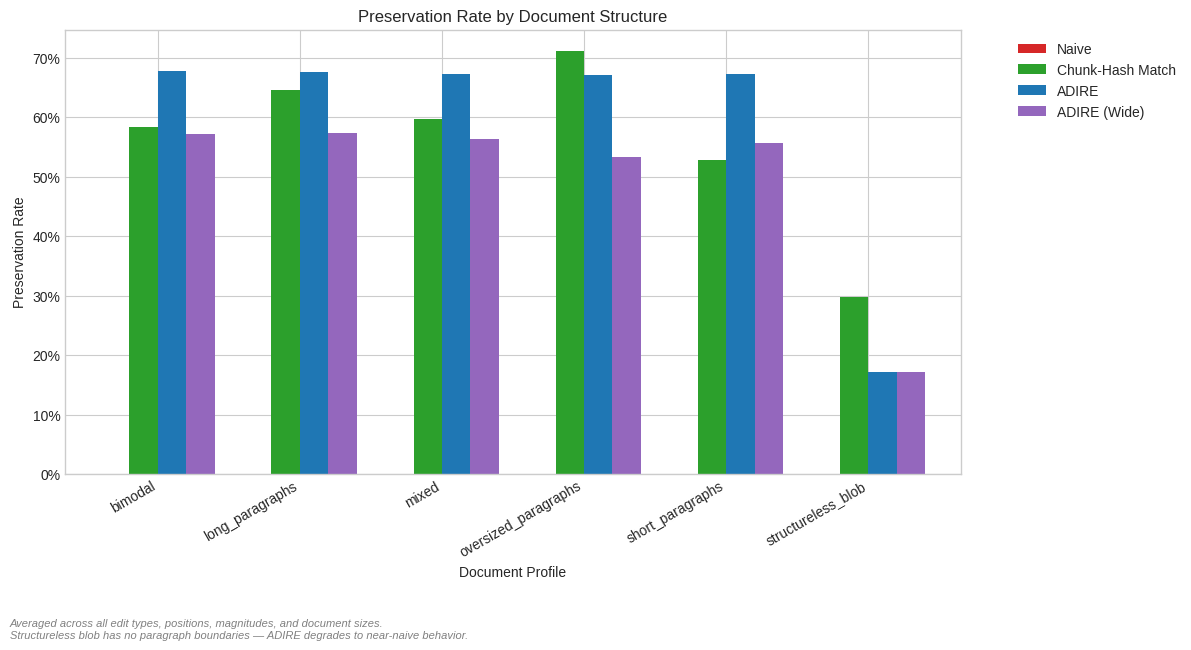

In [5]:
pivoted = pivot_for_grouped_bar(
    single, "document_profile", "preservation_rate",
    strategies=SAME_GRANULARITY_STRATEGIES,
)
fig, ax = plt.subplots()
pivoted.rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.8, ax=ax)
ax.set_xlabel("Document Profile")
ax.set_ylabel("Preservation Rate")
ax.set_title("Preservation Rate by Document Structure")
ax.set_xticklabels(pivoted.index, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Averaged across all edit types, positions, magnitudes, and document sizes.\n"
    "Structureless blob has no paragraph boundaries — ADIRE degrades to near-naive behavior.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig03_preservation_by_structure.png", bbox_inches="tight")
plt.show()

## 4. Preservation Rate by Edit Type

**What it measures**: Same metric (chunks_reused / total_chunks), grouped by edit type. Averaged across all document sizes, profiles, positions, and magnitudes.

**Why this matters**: Different edit types dirty different numbers of chunks. A typo fix changes one paragraph hash, dirtying one chunk. A section rewrite replaces multiple consecutive paragraphs, dirtying several chunks. Append adds content at the end without touching existing chunks at all.

**Example**: On a 10-chunk document — typo fix dirties 1 chunk → 90% preservation. Section rewrite (magnitude=3) might dirty 2-3 chunks → 70-80% preservation. Paragraph delete removes content from one chunk → 90% preservation, but the chunk is re-formed.

**How to read**: Edit types near 100% for ADIRE are "cheap" edits (most of the document is untouched). Edit types with lower preservation are "expensive" (they touch more of the document). Chunk-hash match will generally be lower than ADIRE due to cascade effects.

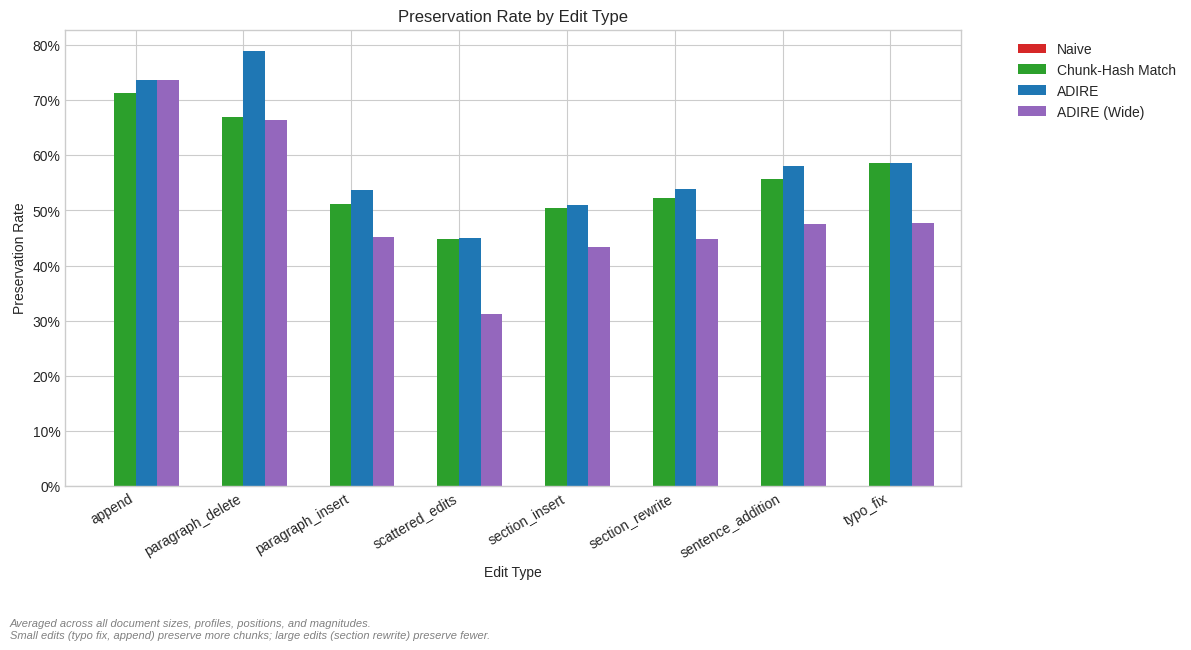

In [6]:
pivoted = pivot_for_grouped_bar(
    single, "edit_type", "preservation_rate",
    strategies=SAME_GRANULARITY_STRATEGIES,
)
fig, ax = plt.subplots()
pivoted.rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.8, ax=ax)
ax.set_xlabel("Edit Type")
ax.set_ylabel("Preservation Rate")
ax.set_title("Preservation Rate by Edit Type")
ax.set_xticklabels(pivoted.index, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Averaged across all document sizes, profiles, positions, and magnitudes.\n"
    "Small edits (typo fix, append) preserve more chunks; large edits (section rewrite) preserve fewer.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig04_preservation_by_edit_type.png", bbox_inches="tight")
plt.show()

## 5. Token Savings Heatmap (Document Size x Edit Type)

**What it measures**: Mean token savings rate for ADIRE, broken out by both document size (rows) and edit type (columns). This is the primary result visualization — it shows the full interaction between the two most important dimensions.

**Why a heatmap?** The bar charts above average over one dimension at a time. This shows both simultaneously, revealing patterns like "typo fixes save 95% on large documents but only 20% on tiny ones" or "section rewrites are expensive regardless of size."

**Example**: The cell at (50K, typo_fix) shows the mean token savings rate across all profiles, positions, magnitudes, and 100 trials for ADIRE processing a typo fix on a 50K-char document.

**How to read**: Darker green = higher savings. Look for the size threshold where ADIRE becomes consistently valuable (most cells turn green). Look for edit types that remain light even at large sizes — those are ADIRE's weak spots.

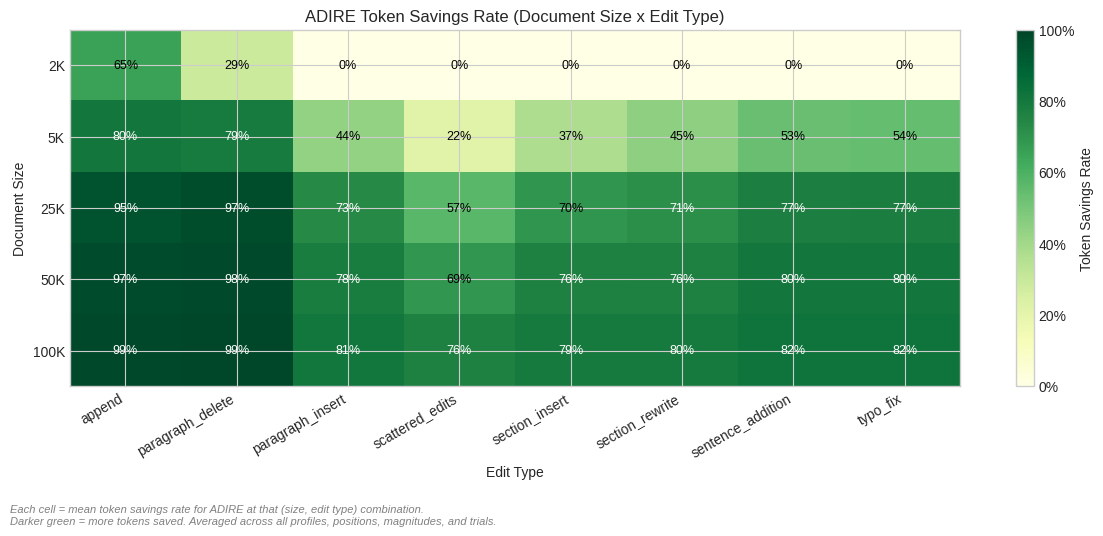

In [7]:
hm = heatmap_data(single, "document_size", "edit_type", "token_savings_rate", "adire")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hm.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(hm.columns)))
ax.set_xticklabels(hm.columns, rotation=30, ha="right")
ax.set_yticks(range(len(hm.index)))
ax.set_yticklabels([format_size_label(x) for x in hm.index])
ax.set_xlabel("Edit Type")
ax.set_ylabel("Document Size")
ax.set_title("ADIRE Token Savings Rate (Document Size x Edit Type)")
for i in range(len(hm.index)):
    for j in range(len(hm.columns)):
        val = hm.values[i, j]
        color = "white" if val > 0.7 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", color=color, fontsize=9)
fig.colorbar(im, ax=ax, label="Token Savings Rate", format=mtick.PercentFormatter(1.0))
fig.text(0.01, -0.02,
    "Each cell = mean token savings rate for ADIRE at that (size, edit type) combination.\n"
    "Darker green = more tokens saved. Averaged across all profiles, positions, magnitudes, and trials.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig05_token_savings_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Cascade Effect: Chunk-Hash Match vs ADIRE by Edit Position

**What it measures**: Preservation rate for chunk-hash match vs ADIRE, grouped by where in the document the edit occurred (top 10%, middle, bottom 10%). Position-independent edit types (append, scattered) are excluded.

**Why this matters**: This is the motivating problem for ADIRE. Chunk-hash match re-chunks from scratch and compares text hashes. If you insert a paragraph near the top, greedy combining shifts all downstream chunk boundaries — every chunk after the insertion has different text, so its hash doesn't match any old chunk. This is the **cascade problem**. Edits near the bottom affect fewer downstream chunks.

ADIRE avoids cascade entirely because it diffs paragraph hash *sequences positionally* — it knows which paragraphs changed and maps them to chunks regardless of where chunk boundaries land.

**Example**: Insert a 200-token paragraph at position 2 in a 10-chunk document. Chunk-hash: chunk 0 might survive (before the insertion), but chunks 1-9 all have shifted boundaries → ~10% preservation. ADIRE: only the chunk containing position 2 is dirty → ~90% preservation.

**How to read**: ADIRE's bars should be roughly equal across positions (position-independent). Chunk-hash bars should drop from bottom → top, showing the cascade effect.

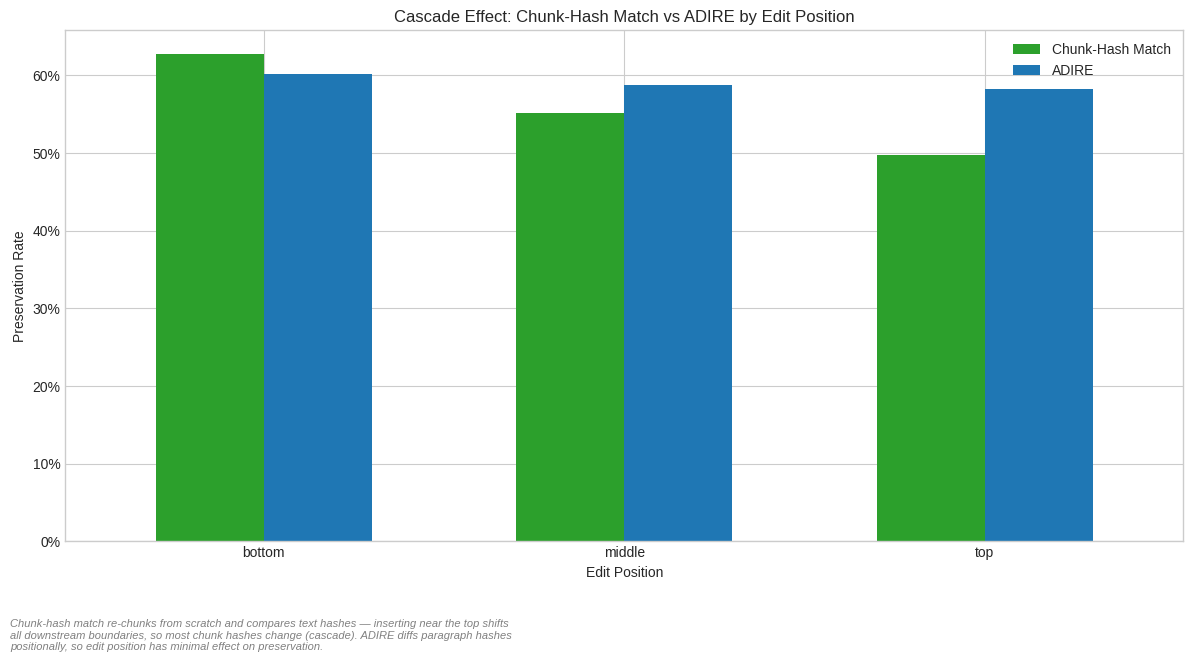

In [8]:
cascade_strategies = ["chunk_hash", "adire"]
cascade_df = single[single["strategy"].isin(cascade_strategies)]
# Exclude position-independent edit types
cascade_df = cascade_df[~cascade_df["edit_type"].isin(["append", "scattered_edits"])]

pivoted = pivot_for_grouped_bar(
    cascade_df, "edit_position", "preservation_rate",
    strategies=cascade_strategies,
)
fig, ax = plt.subplots()
pivoted.rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.6, ax=ax)
ax.set_xlabel("Edit Position")
ax.set_ylabel("Preservation Rate")
ax.set_title("Cascade Effect: Chunk-Hash Match vs ADIRE by Edit Position")
ax.set_xticklabels(pivoted.index, rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
fig.text(0.01, -0.04,
    "Chunk-hash match re-chunks from scratch and compares text hashes — inserting near the top shifts\n"
    "all downstream boundaries, so most chunk hashes change (cascade). ADIRE diffs paragraph hashes\n"
    "positionally, so edit position has minimal effect on preservation.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig06_cascade_by_position.png", bbox_inches="tight")
plt.show()

## 7. Fragmentation Over Edit Chains

**What it measures**: Fragment ratio at each step of a 20-edit chain, averaged across all (document_size, profile) pairs.

`fragment_ratio = chunks below 25% of target size (< 128 tokens for 512 target) / total chunks`

**Why this matters**: ADIRE preserves old chunk boundaries, but over time incremental re-chunking can produce undersized "fragment" chunks. For example: a 2-paragraph chunk [A, B] at 450 tokens gets dirtied when B is edited. The dirty region re-chunks into [B'] at 200 tokens — a valid chunk, but smaller than optimal. Repeated edits can accumulate these fragments. When the fragment ratio exceeds 30%, it's time to defrag (full re-chunk from scratch).

**Example**: After 20 sequential edits, if 4 of 20 chunks are below 128 tokens, fragment_ratio = 20%.

**How to read**: If the line stays below the red dashed threshold (30%), fragmentation is manageable and defrag is rarely needed. If it crosses, the incremental approach needs periodic full re-chunks. The wide-window variant should show lower fragmentation (it re-chunks more aggressively).

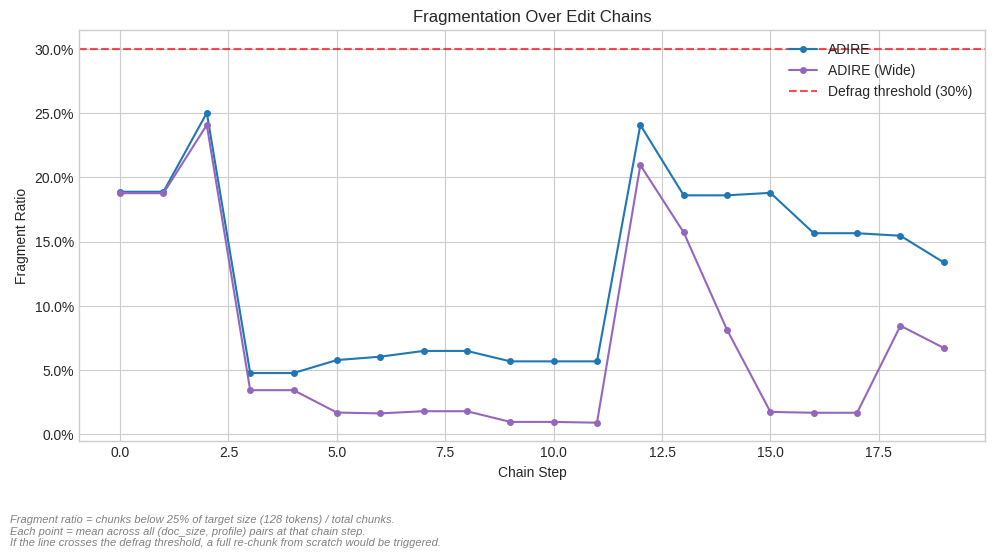

In [9]:
chain_strategies = ["adire", "adire_wide_window"]
chain_frag = chains[chains["strategy"].isin(chain_strategies)]
frag_by_step = chain_frag.groupby(["trial_number", "strategy"])["fragment_ratio"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for strategy in chain_strategies:
    data = frag_by_step[frag_by_step["strategy"] == strategy]
    ax.plot(data["trial_number"], data["fragment_ratio"],
            marker="o", label=STRATEGY_LABELS[strategy], color=STRATEGY_COLORS[strategy], markersize=4)
ax.axhline(y=0.30, color="red", linestyle="--", alpha=0.7, label="Defrag threshold (30%)")
ax.set_xlabel("Chain Step")
ax.set_ylabel("Fragment Ratio")
ax.set_title("Fragmentation Over Edit Chains")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
fig.text(0.01, -0.04,
    "Fragment ratio = chunks below 25% of target size (128 tokens) / total chunks.\n"
    "Each point = mean across all (doc_size, profile) pairs at that chain step.\n"
    "If the line crosses the defrag threshold, a full re-chunk from scratch would be triggered.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig07_fragmentation_chains.png", bbox_inches="tight")
plt.show()

## 8. Chunk Quality: ADIRE vs From-Scratch (Naive)

**What it measures**: Fragment ratio for naive, ADIRE, and ADIRE wide-window, grouped by document size. Naive always re-chunks from scratch, producing optimal chunk boundaries with no fragments. ADIRE preserves old boundaries, which may not be optimal after edits.

**Why this matters**: This quantifies the cost of ADIRE's boundary preservation. If ADIRE produces many more fragments than naive, the chunks it preserves may be lower quality for retrieval (undersized chunks produce poor embeddings). The wide-window variant re-chunks a larger region around each edit, producing boundaries closer to from-scratch quality at the cost of more re-embedding.

**Example**: Naive always has 0% fragment ratio (fresh optimal boundaries). ADIRE might have 5% (a few small chunks from boundary misalignment). ADIRE wide-window might have 2% (wider re-chunk region produces better boundaries).

**How to read**: Lower is better. The gap between naive and ADIRE shows chunk quality cost. The gap between ADIRE and ADIRE wide-window shows how much the wider re-chunk region helps.

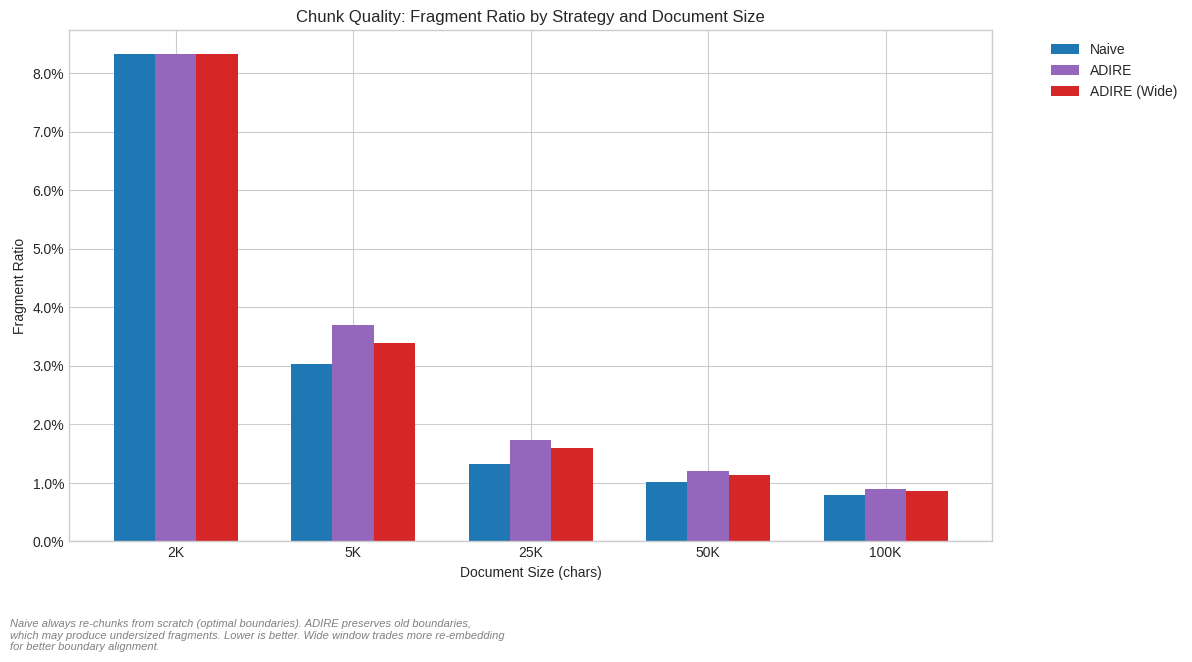

In [10]:
frag_compare = mean_by(
    single[single["strategy"].isin(["naive", "adire", "adire_wide_window"])],
    ["document_size", "strategy"],
    "fragment_ratio",
)
pivoted = frag_compare.pivot_table(index="document_size", columns="strategy", values="fragment_ratio")
cols = [s for s in STRATEGY_ORDER if s in pivoted.columns]
fig, ax = plt.subplots()
pivoted[cols].rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.7, ax=ax)
ax.set_xlabel("Document Size (chars)")
ax.set_ylabel("Fragment Ratio")
ax.set_title("Chunk Quality: Fragment Ratio by Strategy and Document Size")
ax.set_xticklabels([format_size_label(x) for x in pivoted.index], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Naive always re-chunks from scratch (optimal boundaries). ADIRE preserves old boundaries,\n"
    "which may produce undersized fragments. Lower is better. Wide window trades more re-embedding\n"
    "for better boundary alignment.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig08_chunk_quality.png", bbox_inches="tight")
plt.show()

## 9. Cost Savings Estimate

**What it measures**: Estimated dollar savings per edit compared to naive, using approximate embedding API pricing ($0.00002 per 1K tokens, roughly text-embedding-3-small rates).

`cost_per_edit = tokens_re-embedded / 1000 × $0.00002`
`savings = naive_cost − strategy_cost`

**Why this matters**: Token savings rate is abstract. This translates it into dollars. The per-edit savings are tiny (fractions of a cent), but they compound: a note-taking app with 10K users making 5 edits/day on documents averaging 50K chars = 50K edits/day. Even $0.0001 savings per edit = $5/day = ~$1,800/year.

**Example**: A 100K-char document (~25K tokens, ~49 chunks). Naive re-embeds all 49 chunks = ~$0.0005. ADIRE re-embeds 5 chunks = ~$0.00005. Savings = ~$0.00045 per edit.

**How to read**: Taller bars = more savings. The absolute values are small per edit — the value is in aggregate at scale.

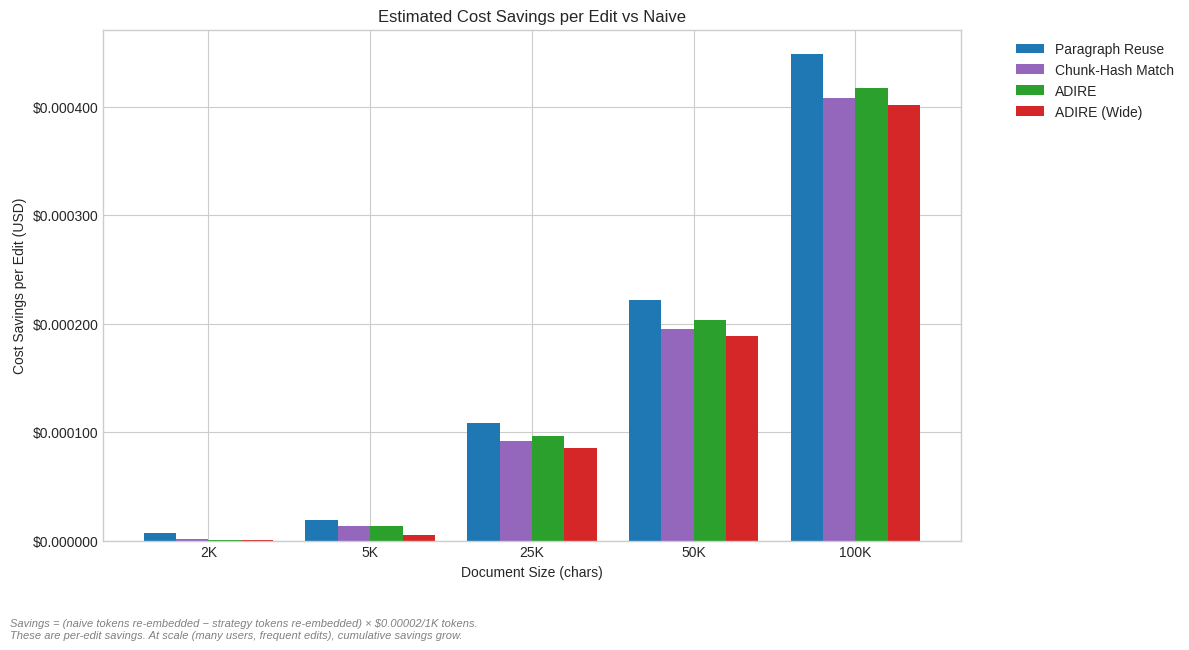


Mean cost savings per edit (USD) vs naive:
strategy       Paragraph Reuse  Chunk-Hash Match       ADIRE  ADIRE (Wide)
document_size                                                             
2000               $0.00000708       $0.00000194 $0.00000093   $0.00000093
5000               $0.00001963       $0.00001357 $0.00001356   $0.00000541
25000              $0.00010859       $0.00009185 $0.00009683   $0.00008528
50000              $0.00022153       $0.00019521 $0.00020323   $0.00018901
100000             $0.00044837       $0.00040775 $0.00041745   $0.00040143


In [11]:
cost_df = compute_cost_savings(single)
cost_by_size = cost_df.groupby(["document_size", "strategy"])["cost_savings_usd"].mean().reset_index()
pivoted = cost_by_size.pivot_table(index="document_size", columns="strategy", values="cost_savings_usd")
# Exclude naive (savings are always 0)
cols = [s for s in STRATEGY_ORDER if s in pivoted.columns and s != "naive"]
fig, ax = plt.subplots()
pivoted[cols].rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(pivoted.columns), width=0.8, ax=ax)
ax.set_xlabel("Document Size (chars)")
ax.set_ylabel("Cost Savings per Edit (USD)")
ax.set_title("Estimated Cost Savings per Edit vs Naive")
ax.set_xticklabels([format_size_label(x) for x in pivoted.index], rotation=0)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("$%.6f"))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.text(0.01, -0.04,
    "Savings = (naive tokens re-embedded − strategy tokens re-embedded) × $0.00002/1K tokens.\n"
    "These are per-edit savings. At scale (many users, frequent edits), cumulative savings grow.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig09_cost_savings.png", bbox_inches="tight")
plt.show()

print("\nMean cost savings per edit (USD) vs naive:")
print(pivoted[cols].rename(columns=STRATEGY_LABELS).to_string(float_format="${:.8f}".format))

## 10. Algorithm Overhead vs API Latency Savings

**What it measures**: Two components of end-to-end latency, shown side by side:
- **Left (Algorithm CPU Time)**: Wall-clock time for the strategy's computation (paragraph splitting, diffing, mapping, re-chunking). Measured via `time.perf_counter()`.
- **Right (Estimated API Latency)**: Modeled embedding API time = `ceil(chunks_re-embedded / batch_size) × latency_per_batch`. Uses batch_size=100 and 200ms per batch.

**Why this matters**: ADIRE does more CPU work than naive (it has to diff and map). But if that extra CPU work avoids embedding API calls, the net latency is lower. This chart shows both components so you can see where the tradeoff tips.

**Example**: Naive on a 100K doc: ~0.1ms CPU + 200ms API (1 batch of ~49 chunks) = 200.1ms total. ADIRE: ~0.5ms CPU + 200ms API (1 batch of ~5 chunks) = 200.5ms. Wait — both use 1 batch? Yes, if chunks_re-embedded < batch_size, both need exactly 1 API call. The latency savings only appear when naive needs multiple batches (very large documents or small batch sizes).

**How to read**: Left panel shows ADIRE's overhead. Right panel shows the API savings. The strategy wins when its API savings exceed its CPU overhead.

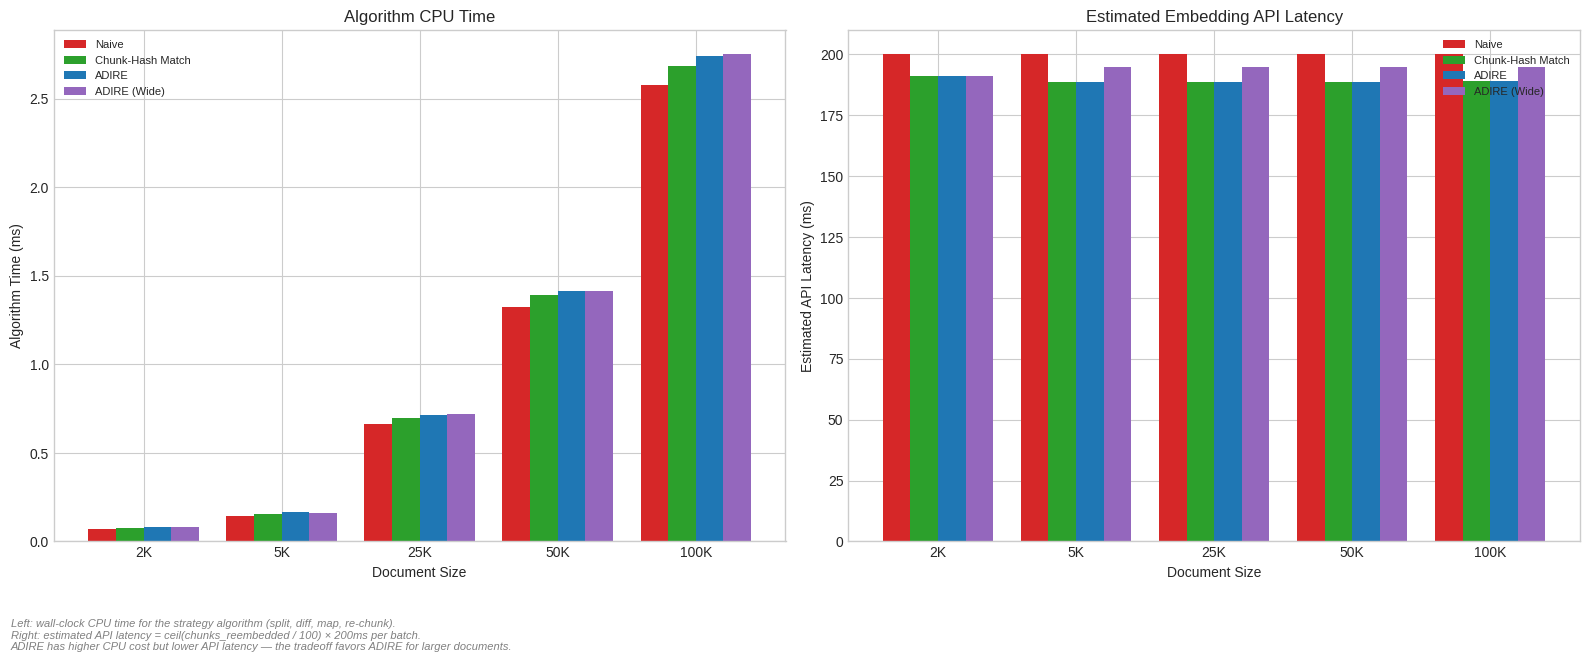

In [12]:
latency_strategies = ["naive", "chunk_hash", "adire", "adire_wide_window"]
latency_df = single[single["strategy"].isin(latency_strategies)]

algo_time = mean_by(latency_df, ["document_size", "strategy"], "algorithm_time_ms")
api_time = mean_by(latency_df, ["document_size", "strategy"], "estimated_api_latency_ms")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: algorithm time
algo_pivot = algo_time.pivot_table(index="document_size", columns="strategy", values="algorithm_time_ms")
cols = [s for s in latency_strategies if s in algo_pivot.columns]
algo_pivot[cols].rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(cols), ax=axes[0], width=0.8)
axes[0].set_xlabel("Document Size")
axes[0].set_ylabel("Algorithm Time (ms)")
axes[0].set_title("Algorithm CPU Time")
axes[0].set_xticklabels([format_size_label(x) for x in algo_pivot.index], rotation=0)
axes[0].legend(fontsize=8)

# Right: estimated API latency
api_pivot = api_time.pivot_table(index="document_size", columns="strategy", values="estimated_api_latency_ms")
api_pivot[cols].rename(columns=STRATEGY_LABELS).plot(kind="bar", color=colors_for(cols), ax=axes[1], width=0.8)
axes[1].set_xlabel("Document Size")
axes[1].set_ylabel("Estimated API Latency (ms)")
axes[1].set_title("Estimated Embedding API Latency")
axes[1].set_xticklabels([format_size_label(x) for x in api_pivot.index], rotation=0)
axes[1].legend(fontsize=8)

fig.text(0.01, -0.04,
    "Left: wall-clock CPU time for the strategy algorithm (split, diff, map, re-chunk).\n"
    "Right: estimated API latency = ceil(chunks_reembedded / 100) × 200ms per batch.\n"
    "ADIRE has higher CPU cost but lower API latency — the tradeoff favors ADIRE for larger documents.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig10_latency_components.png", bbox_inches="tight")
plt.show()

## 11. Estimated Total Latency by Document Size

**What it measures**: End-to-end latency = algorithm CPU time + estimated API latency, plotted as a line chart across document sizes.

**Why this matters**: This is the bottom line for user-perceived performance. Even if ADIRE saves tokens, it doesn't help if its CPU overhead makes the total time slower. This chart shows the crossover point — the document size above which ADIRE is faster than naive end-to-end.

**Example**: At 2K chars, all strategies take ~200ms (1 API batch dominates). At 100K chars, naive might take 200ms (still 1 batch of ~49 chunks), but if the batch size were smaller (e.g., 20), naive would need 3 batches = 600ms while ADIRE needs 1 batch = 200ms.

**How to read**: Lower is better. Where ADIRE's line drops below naive's, ADIRE is faster. Note that with batch_size=100, the API latency is often the same (1 batch) for all strategies — the savings are primarily in token cost, not latency, at this batch size.

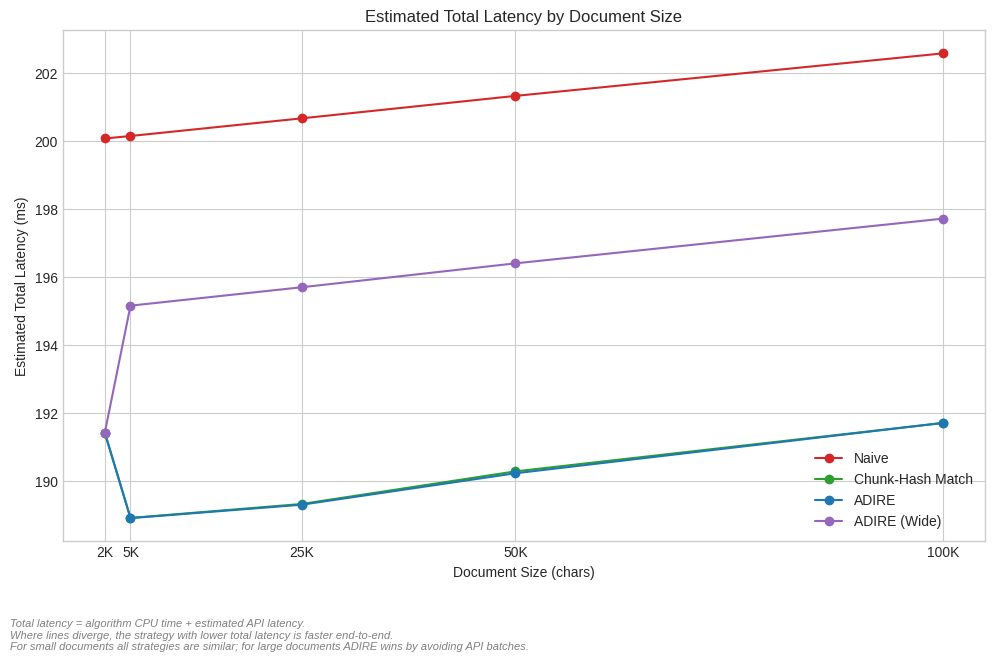

In [13]:
total_latency = mean_by(latency_df, ["document_size", "strategy"], "estimated_total_latency_ms")

fig, ax = plt.subplots(figsize=(10, 6))
for strategy in latency_strategies:
    data = total_latency[total_latency["strategy"] == strategy].sort_values("document_size")
    ax.plot(data["document_size"], data["estimated_total_latency_ms"],
            marker="o", label=STRATEGY_LABELS[strategy], color=STRATEGY_COLORS[strategy], markersize=6)
ax.set_xlabel("Document Size (chars)")
ax.set_ylabel("Estimated Total Latency (ms)")
ax.set_title("Estimated Total Latency by Document Size")
ax.set_xticks(sorted(latency_df["document_size"].unique()))
ax.set_xticklabels([format_size_label(x) for x in sorted(latency_df["document_size"].unique())])
ax.legend()
fig.text(0.01, -0.04,
    "Total latency = algorithm CPU time + estimated API latency.\n"
    "Where lines diverge, the strategy with lower total latency is faster end-to-end.\n"
    "For small documents all strategies are similar; for large documents ADIRE wins by avoiding API batches.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig11_total_latency.png", bbox_inches="tight")
plt.show()

## 12. Token Savings Heatmap (Document Profile × Document Size)

**What it measures**: Mean ADIRE token savings rate for each (profile, size) combination. This shows the interaction between document structure and document size — which the individual bar charts average away.

**Why this matters**: A "mixed" profile at 50K chars has many paragraphs and many chunks, giving ADIRE fine-grained change detection. An "oversized_paragraphs" profile at the same size has few paragraphs (each exceeding the chunk budget), so each edit dirties a larger fraction of the document. A "structureless_blob" has essentially one chunk regardless of size.

**How to read**: Each cell shows ADIRE's mean token savings for that specific (profile, size) pair, averaged across all edit types, positions, magnitudes, and trials. Darker green = more savings.

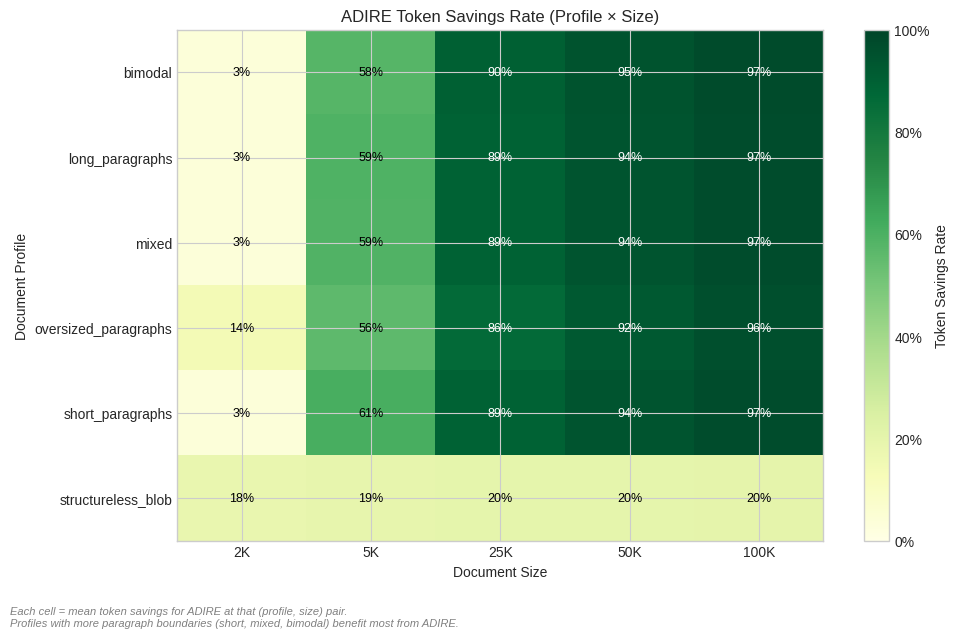

In [14]:
hm = heatmap_data(single, "document_profile", "document_size", "token_savings_rate", "adire")
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(hm.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(hm.columns)))
ax.set_xticklabels([format_size_label(x) for x in hm.columns], rotation=0)
ax.set_yticks(range(len(hm.index)))
ax.set_yticklabels(hm.index)
ax.set_xlabel("Document Size")
ax.set_ylabel("Document Profile")
ax.set_title("ADIRE Token Savings Rate (Profile × Size)")
for i in range(len(hm.index)):
    for j in range(len(hm.columns)):
        val = hm.values[i, j]
        color = "white" if val > 0.7 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", color=color, fontsize=9)
fig.colorbar(im, ax=ax, label="Token Savings Rate", format=mtick.PercentFormatter(1.0))
fig.text(0.01, -0.02,
    "Each cell = mean token savings for ADIRE at that (profile, size) pair.\n"
    "Profiles with more paragraph boundaries (short, mixed, bimodal) benefit most from ADIRE.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig12_token_savings_profile_size.png", bbox_inches="tight")
plt.show()

## 13. Realistic Scenarios

The charts above slice by one or two dimensions at a time. This section filters the data to specific combinations that represent how real users actually edit documents. Each scenario defines a document profile, size range, and the most likely edit types — then shows all 5 strategies head-to-head.

**Scenarios:**
- **Typical note**: mixed profile, 25K-50K chars, common edits (typo fix, sentence addition, paragraph insert). This is the bread-and-butter use case for a note-taking app.
- **Power user note**: mixed profile, 100K chars (max tier), all edit types. Stress-tests ADIRE on the largest documents.
- **Bullet-heavy note**: short_paragraphs profile, 5K-25K chars, common edits. Many small paragraphs = many chunks = fine-grained reuse.
- **Pasted content**: structureless_blob + oversized_paragraphs profiles, any size. The degenerate case where ADIRE has limited value.

/tmp/ipykernel_143745/3050750309.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([STRATEGY_LABELS[s] for s in means.index], rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_143745/3050750309.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([STRATEGY_LABELS[s] for s in means.index], rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_143745/3050750309.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([STRATEGY_LABELS[s] for s in means.index], rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_143745/3050750309.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([STR

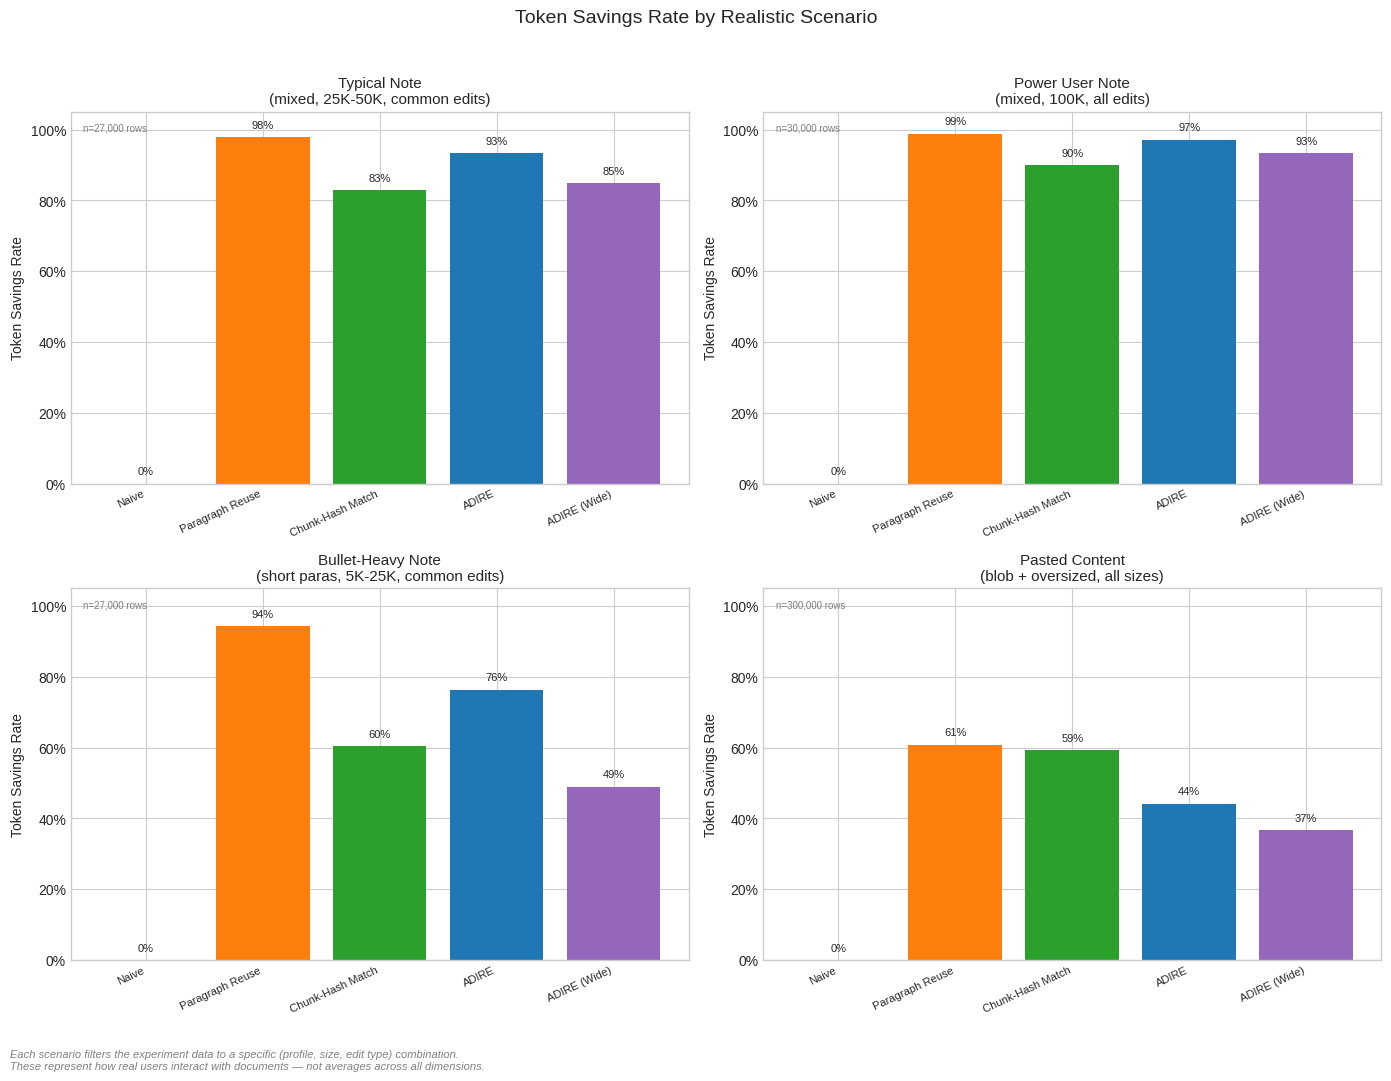

In [15]:
common_edits = ["typo_fix", "sentence_addition", "paragraph_insert"]

scenarios = {
    "Typical Note\n(mixed, 25K-50K, common edits)": single[
        (single["document_profile"] == "mixed")
        & (single["document_size"].isin([25000, 50000]))
        & (single["edit_type"].isin(common_edits))
    ],
    "Power User Note\n(mixed, 100K, all edits)": single[
        (single["document_profile"] == "mixed")
        & (single["document_size"] == 100000)
    ],
    "Bullet-Heavy Note\n(short paras, 5K-25K, common edits)": single[
        (single["document_profile"] == "short_paragraphs")
        & (single["document_size"].isin([5000, 25000]))
        & (single["edit_type"].isin(common_edits))
    ],
    "Pasted Content\n(blob + oversized, all sizes)": single[
        single["document_profile"].isin(["structureless_blob", "oversized_paragraphs"])
    ],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, scenario_df) in enumerate(scenarios.items()):
    ax = axes[idx]
    means = scenario_df.groupby("strategy")["token_savings_rate"].mean()
    means = means.reindex(STRATEGY_ORDER)
    bars = ax.bar(
        [STRATEGY_LABELS[s] for s in means.index],
        means.values,
        color=colors_for(means.index),
    )
    ax.set_ylabel("Token Savings Rate")
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in means.index], rotation=25, ha="right", fontsize=8)
    # Annotate bars
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", va="bottom", fontsize=8)
    ax.text(0.02, 0.97, f"n={len(scenario_df):,} rows",
            transform=ax.transAxes, fontsize=7, color="gray", va="top")

fig.suptitle("Token Savings Rate by Realistic Scenario", fontsize=14, y=1.02)
fig.text(0.01, -0.02,
    "Each scenario filters the experiment data to a specific (profile, size, edit type) combination.\n"
    "These represent how real users interact with documents — not averages across all dimensions.",
    fontsize=8, color="gray", style="italic", va="top")
plt.tight_layout()
plt.savefig("../notebooks/fig13_realistic_scenarios.png", bbox_inches="tight")
plt.show()

In [16]:
# Summary table of scenarios
print("Scenario Summary — Mean Token Savings Rate")
print("=" * 75)
for name, scenario_df in scenarios.items():
    clean_name = name.replace("\n", " ")
    print(f"\n{clean_name}")
    means = scenario_df.groupby("strategy")["token_savings_rate"].mean()
    means = means.reindex(STRATEGY_ORDER)
    for strategy, val in means.items():
        print(f"  {STRATEGY_LABELS[strategy]:25s} {val:.1%}")
    # Also show ADIRE vs chunk-hash delta
    if "adire" in means.index and "chunk_hash" in means.index:
        delta = means["adire"] - means["chunk_hash"]
        print(f"  {'ADIRE advantage over chunk-hash':25s} {delta:+.1%}")

Scenario Summary — Mean Token Savings Rate

Typical Note (mixed, 25K-50K, common edits)
  Naive                     0.0%
  Paragraph Reuse           97.8%
  Chunk-Hash Match          82.9%
  ADIRE                     93.4%
  ADIRE (Wide)              84.9%
  ADIRE advantage over chunk-hash +10.5%

Power User Note (mixed, 100K, all edits)
  Naive                     0.0%
  Paragraph Reuse           98.8%
  Chunk-Hash Match          90.0%
  ADIRE                     97.1%
  ADIRE (Wide)              93.3%
  ADIRE advantage over chunk-hash +7.1%

Bullet-Heavy Note (short paras, 5K-25K, common edits)
  Naive                     0.0%
  Paragraph Reuse           94.4%
  Chunk-Hash Match          60.4%
  ADIRE                     76.4%
  ADIRE (Wide)              48.9%
  ADIRE advantage over chunk-hash +16.0%

Pasted Content (blob + oversized, all sizes)
  Naive                     0.0%
  Paragraph Reuse           60.9%
  Chunk-Hash Match          59.3%
  ADIRE                     44.1%
  ADI

## Summary

Key findings from the simulation:

In [17]:
adire_single = single[single["strategy"] == "adire"]
chunk_hash_single = single[single["strategy"] == "chunk_hash"]
para_reuse_single = single[single["strategy"] == "paragraph_reuse"]

print("=" * 70)
print("ADIRE SIMULATION RESULTS SUMMARY")
print("=" * 70)

print("\n--- Token Savings Rate (mean across all edits) ---")
for size in sorted(single["document_size"].unique()):
    adire_savings = adire_single[adire_single["document_size"] == size]["token_savings_rate"].mean()
    ch_savings = chunk_hash_single[chunk_hash_single["document_size"] == size]["token_savings_rate"].mean()
    pr_savings = para_reuse_single[para_reuse_single["document_size"] == size]["token_savings_rate"].mean()
    print(f"  {format_size_label(size):>5s}: ADIRE={adire_savings:.1%}  Chunk-Hash={ch_savings:.1%}  Para-Reuse={pr_savings:.1%}")

print("\n--- Cascade Effect (preservation rate by position) ---")
pos_dep = single[~single["edit_type"].isin(["append", "scattered_edits"])]
for pos in ["top", "middle", "bottom"]:
    adire_rate = pos_dep[(pos_dep["strategy"] == "adire") & (pos_dep["edit_position"] == pos)]["preservation_rate"].mean()
    ch_rate = pos_dep[(pos_dep["strategy"] == "chunk_hash") & (pos_dep["edit_position"] == pos)]["preservation_rate"].mean()
    print(f"  {pos:>6s}: ADIRE={adire_rate:.1%}  Chunk-Hash={ch_rate:.1%}  (delta={adire_rate - ch_rate:+.1%})")

print("\n--- Chain Fragmentation (ADIRE, mean fragment_ratio) ---")
adire_chain = chains[chains["strategy"] == "adire"]
first_step = adire_chain[adire_chain["trial_number"] == 0]["fragment_ratio"].mean()
last_step = adire_chain[adire_chain["trial_number"] == adire_chain["trial_number"].max()]["fragment_ratio"].mean()
print(f"  Step 0: {first_step:.1%}")
print(f"  Step {int(adire_chain['trial_number'].max())}: {last_step:.1%}")
print(f"  Defrag threshold (30%): {'EXCEEDED' if last_step > 0.30 else 'NOT exceeded'}")

print("\n--- Key Takeaways ---")
large_savings = adire_single[adire_single["document_size"] >= 50000]["token_savings_rate"].mean()
print(f"  ADIRE saves {large_savings:.0%} of embedding tokens for large documents (50K+ chars)")
typo_savings = adire_single[adire_single["edit_type"] == "typo_fix"]["token_savings_rate"].mean()
print(f"  Typo fixes (most common edit) save {typo_savings:.0%} of tokens with ADIRE")
print("=" * 70)

ADIRE SIMULATION RESULTS SUMMARY

--- Token Savings Rate (mean across all edits) ---
     2K: ADIRE=7.6%  Chunk-Hash=13.3%  Para-Reuse=60.5%
     5K: ADIRE=51.9%  Chunk-Hash=50.8%  Para-Reuse=73.8%
    25K: ADIRE=77.4%  Chunk-Hash=73.1%  Para-Reuse=86.4%
    50K: ADIRE=81.7%  Chunk-Hash=78.2%  Para-Reuse=88.8%
   100K: ADIRE=84.1%  Chunk-Hash=82.0%  Para-Reuse=90.1%

--- Cascade Effect (preservation rate by position) ---
     top: ADIRE=58.3%  Chunk-Hash=49.7%  (delta=+8.6%)
  middle: ADIRE=58.7%  Chunk-Hash=55.2%  (delta=+3.5%)
  bottom: ADIRE=60.1%  Chunk-Hash=62.7%  (delta=-2.5%)

--- Chain Fragmentation (ADIRE, mean fragment_ratio) ---
  Step 0: 18.9%
  Step 19: 13.4%
  Defrag threshold (30%): NOT exceeded

--- Key Takeaways ---
  ADIRE saves 83% of embedding tokens for large documents (50K+ chars)
  Typo fixes (most common edit) save 59% of tokens with ADIRE
